# Анализ данных

Смотрю глазами на три таблицы, прежде чем что-то строить. Хочу понять: что за запросы, где живут ответы, какие сигналы вообще есть.
Все выводы этого разбора дальше превращаются в элементы решения.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# данные лежат в ../data (путь можно переопределить переменной AVITO_DATA)
DATA = Path(os.environ.get("AVITO_DATA", "../data"))
train = pd.read_parquet(DATA / "train.parquet")
bq = pd.read_parquet(DATA / "benchmark_queries.parquet")
bi = pd.read_parquet(DATA / "benchmark_items.parquet")
print("train:", len(train))
print("запросов:", len(bq))
print("объявлений:", len(bi))

train: 497673
запросов: 2452
объявлений: 189212


## Сколько корпуса видел train

Если почти все ответы бенчмарка уже выбирали в train, можно запоминать. Проверяю пересечение.

In [2]:
corpus = set(bi["item_id"])
seen_items = set(train["item_id"]) & corpus
print("уникальных ответов train в корпусе:", len(seen_items))
print("доля корпуса:", round(100 * len(seen_items) / len(corpus), 1), "%")
pairs_in = train["item_id"].isin(corpus).sum()
print("пар train с ответом в корпусе:", pairs_in, "из", len(train))

уникальных ответов train в корпусе: 18142
доля корпуса: 9.6 %


пар train с ответом в корпусе: 33010 из 497673


## Город решает почти всё

Проверяю главную догадку: ищут рядом с домом.

In [3]:
same = (train["search_location_id"] == train["item_location_id"]).mean()
print("ответ в своем городе:", round(100 * same, 1), "%")
city_sizes = bi["item_location_id"].value_counts()
print("медианный город корпуса:", int(city_sizes.median()), "объявлений")
print("топ-5 городов:", dict(city_sizes.head(5)))

ответ в своем городе: 83.1 %
медианный город корпуса: 5 объявлений
топ-5 городов: {637640: np.int64(19543), 653240: np.int64(12145), 633540: np.int64(4494), 650400: np.int64(3659), 641780: np.int64(3178)}


## Категории почти не разделяют

Смотрю, поможет ли категория поиска отфильтровать лишнее.

In [4]:
print("категорий поиска:", bq["search_category"].nunique())
print(bq["search_category"].value_counts().head())
match = (train["search_category"].astype(str) == train["item_category_id"].astype(str)).mean()
print("совпадение категории в парах train:", round(match, 4))

категорий поиска: 2
search_category
114    2230
0       222
Name: count, dtype: int64


совпадение категории в парах train: 0.9999


## Как далеко выбирают

Центр города считаю как медиану координат выбранных из него объявлений. Смотрю распределение расстояний: вдруг радиус режет много ответов.

дальше 30 км: 4.3 %
дальше 100 км: 2.2 %


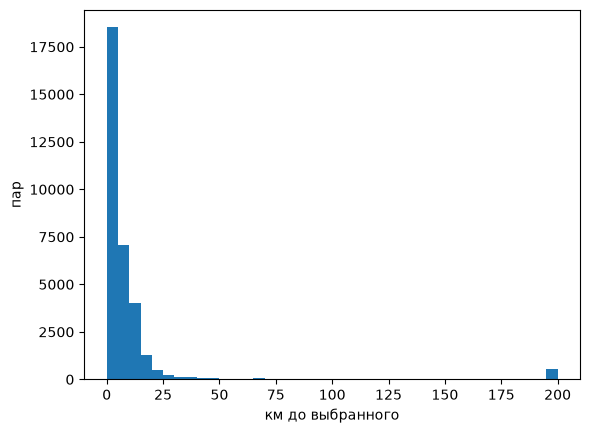

In [5]:
def haversine(clat, clon, lats, lons):
    r = 6371.0
    a1, a2 = np.radians(clat), np.radians(lats)
    d1, d2 = np.radians(lats - clat), np.radians(lons - clon)
    h = np.sin(d1 / 2) ** 2 + np.cos(a1) * np.cos(a2) * np.sin(d2 / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(h))

tr_lat = pd.to_numeric(train["item_latitude"], errors="coerce")
tr_lon = pd.to_numeric(train["item_longitude"], errors="coerce")
cent = train.assign(lat=tr_lat, lon=tr_lon).groupby("search_location_id")[["lat", "lon"]].median()
ev = train[train["item_id"].isin(corpus)]
dd = haversine(ev["search_location_id"].map(cent["lat"]).to_numpy(),
                ev["search_location_id"].map(cent["lon"]).to_numpy(),
                pd.to_numeric(ev["item_latitude"], errors="coerce").to_numpy(),
                pd.to_numeric(ev["item_longitude"], errors="coerce").to_numpy())
ok = dd[~np.isnan(dd)]
print("дальше 30 км:", round(100 * np.mean(ok > 30), 1), "%")
print("дальше 100 км:", round(100 * np.mean(ok > 100), 1), "%")
plt.hist(np.clip(ok, 0, 200), bins=40)
plt.xlabel("км до выбранного")
plt.ylabel("пар")
plt.show()

## Фильтры совпадают с параметрами дословно

Смотрю, есть ли фильтры у запросов и теми ли словами они написаны, что параметры объявлений.

In [6]:
nonempty = (bq["search_infm_params_text"].fillna("").str.strip() != "").mean()
print("запросов с фильтрами:", round(100 * nonempty, 1), "%")
row = train.iloc[0]
print("запрос:", row["search_query"], "|", row["search_infm_params_text"])
print("параметры:", str(row["item_infm_params_text"])[:150])

запросов с фильтрами: 36.9 %
запрос: скупка телевизоров | 
параметры: Вид услуги Место оказания услуг Первомайский пр-т, 66 Тип стоимости за услугу Работаете с юрлицами и ИП Опыт работы 10 лет и больше Гарантия на выполн


## Длины текстов

Запросы короткие, описания длинные — проверяю числами, это определит конструкцию документа.

In [7]:
print("медиана длины запроса:", int(bq["search_query"].str.len().median()))
print("медиана заголовка:", int(bi["item_title_raw"].str.len().median()))
print("медиана описания:", int(bi["item_description_raw"].fillna("").str.len().median()))

медиана длины запроса: 22
медиана заголовка: 35


медиана описания: 1054


## Что я вынес из разбора

1. Корпус train почти не покрывает (меньше 10%) — запоминать ответы бесполезно, нужен обобщающий поиск.
2. Город — главный сигнал: больше 80% ответов свои. Но резать строго по городу нельзя: соседи и дальние выборы есть.
3. Категория почти не разделяет — на неё не опираюсь.
4. Дальше 30 км выбирают редко (~4%) — радиус с запасом покрывает почти всё.
5. Фильтры написаны теми же словами, что параметры, — их стоит использовать отдельно.
6. Запросы короткие, описания длинные и шумные в хвосте — документ собираю из заголовка и начала описания.